# Análisis de Violencia INE

Cuaderno de análisis sobre el conjunto de datos **Base_Violencia_INE_Unificada_LIMPIA.csv**.

In [35]:
# Verificación e instalación de dependencias requeridas
import importlib.util
import subprocess
import sys

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
    "scikit-learn": "sklearn",
    "pyarrow": "pyarrow",
}

missing = [
    pip_name
    for pip_name, module_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing:
    print("Instalando paquetes faltantes:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
    print("Instalación completada.")
else:
    print("Todas las dependencias ya están instaladas.")

Todas las dependencias ya están instaladas.


## 1. Fundamentación

In [36]:
# 1) Importaciones y configuración
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import re
import unicodedata
from sklearn.preprocessing import MinMaxScaler

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

In [37]:
# 2) Definición de rutas de la base de datos
candidate_paths = [
    Path("Base_Violencia_INE_Unificada_LIMPIA.csv"),
    Path("data/raw/Base_Violencia_INE_Unificada_LIMPIA.csv"),
    Path("../data/raw/Base_Violencia_INE_Unificada_LIMPIA.csv"),
]

DATA_PATH = None
for p in candidate_paths:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontró Base_Violencia_INE_Unificada_LIMPIA.csv en rutas esperadas."
    )

print(f"Archivo de entrada: {DATA_PATH.resolve()}")

Archivo de entrada: C:\Users\jmo\Documents\MineriaDeDatos\proyecto_01_mineria_datos\Cuaderno Jupyter para Analisis\Base_Violencia_INE_Unificada_LIMPIA.csv


## 2. Depuración y Estandarización de Datos

In [38]:
def limpiar_datos(filepath):
    print("Cargando datos...")
    df = pd.read_csv(filepath, low_memory=False)

    # Eliminar columnas completamente vacías
    df.dropna(how="all", axis=1, inplace=True)

    # Selección de variables numéricas relevantes por patrón
    patron = re.compile(r"otr[oa]s|victimas|agresores|hijos|hij", flags=re.IGNORECASE)
    cols_numericas = [col for col in df.columns if patron.search(col)]
    if "agr_edad" in df.columns and "agr_edad" not in cols_numericas:
        cols_numericas.append("agr_edad")

    print("Transformando y limpiando variables numéricas...")
    for col in cols_numericas:
        df[col] = df[col].astype(str)
        df[col] = df[col].str.replace("98 y más", "98", regex=False)
        df[col] = df[col].str.replace(r"(?i)ningun[oa]", "0", regex=True)
        df[col] = df[col].replace(["Ignorado", "No indica", "NA", "nan", "<NA>"], np.nan)
        df[col] = pd.to_numeric(df[col], errors="coerce")

    print("Formateando fechas...")
    if "fecha_hecho_limpia" in df.columns:
        df["fecha_hecho_limpia"] = pd.to_datetime(df["fecha_hecho_limpia"], errors="coerce")
        df = df.dropna(subset=["fecha_hecho_limpia"])

    print("Limpieza finalizada.")
    return df

In [39]:
df = limpiar_datos(DATA_PATH)
print("Dimensiones del dataset limpio:", df.shape)
df.head()

Cargando datos...
Transformando y limpiando variables numéricas...
Formateando fechas...
Limpieza finalizada.
Dimensiones del dataset limpio: (515946, 70)


,anio_registro,fecha_hecho_limpia,departamento_limpio,sexo_limpio,edad_limpia,etnia_limpia,quien_reporta,total_hijos,num_hij_hom,num_hij_muj,vic_alfab,vic_escolaridad,vic_est_civ,vic_nacional,vic_trabaja,vic_ocup,vic_dedica,vic_disc,tipo_discaq,vic_rel_agr,otras_victimas,vic_otras_hom,vic_otras_muj,vic_otras_n_os,vic_otras_n_as,hec_area,hec_tipagre,hec_recur_denun,inst_donde_denuncio,agr_sexo,agr_edad,agr_alfab,agr_escolaridad,agr_est_civ,agr_gurpet,agr_nacional,agr_trabaja,agr_ocup,agr_dedica,inst_denun_hecho,medidas_seguridad,agr_grupet,ley_aplicable,agresores_otros_total,agr_otros_hom,agr_otras_muj,agr_otros_n_os,agr_otras_n_as,tipo_medida,organismo_jurisdiccional,conducente,articulovif1,articulovif2,articulovif3,articulovif4,articulovcm1,articulovcm2,articulovcm3,articulovcm4,articulocodpen1,articulocodpen2,articulocodpen3,articulocodpen4,articulotras1,articulotras2,articulotras3,articulotras4,organismo_remite,filter,numero_boleta
0,2008,2008-01-04,Villa Nueva,Mujer,21.0,Ladinos(as),Víctima,2.0,2.0,0.0,Alfabeta,Tercero primaria,Unidos(as),Guatemalteca,Si trabaja por un salario o ingreso,Vendedores ambulantes de productos no comestibles,NaN,Con discapacidad,Ignorado,Conviviente,2.0,0.0,0.0,2.0,0.0,Urbana,Física-psicológica,No,NaN,Hombres,25.0,Alfabeta,Sexto primaria,Unidos(as),Ladinos(as),Guatemalteca,Si trabaja por un salario o ingreso,Vendedores ambulantes de productos comestibles,NaN,Organismo Judicial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2008,2007-12-02,Guatemala,Mujer,43.0,No indica,Víctima,3.0,2.0,1.0,Alfabeta,Segundo primaria,Casados(as),Guatemalteca,Si trabaja por un salario o ingreso,Personal domestico,NaN,Sin discapacidad,NaN,Esposos(a),3.0,2.0,1.0,0.0,0.0,Urbana,Física-psicológica-patrimonial,No,NaN,Hombres,NaN,Alfabeta,Básico grado ignorado,Casados(as),No indica,Guatemalteca,Si trabaja por un salario o ingreso,Persona de partería y enfermería,NaN,Procuraduría de los Derechos Humanos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2008,2008-01-06,Guatemala,Mujer,43.0,Ladinos(as),Víctima,2.0,1.0,1.0,Alfabeta,Primaria grado ignorado,Solteros(as),Guatemalteca,Si trabaja por un salario o ingreso,Niñeras y celadoras infantiles,NaN,Sin discapacidad,NaN,Ex-cónyuges,2.0,0.0,0.0,1.0,1.0,Urbana,Psicológica-patrimonial,Si,Ministerio Público,Hombres,41.0,Alfabeta,Primaria grado ignorado,Solteros(as),Ladinos(as),Guatemalteca,Si trabaja por un salario o ingreso,"Panaderos, pasteleros y confiteros",NaN,Procuraduría de los Derechos Humanos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2008,2008-01-08,Guatemala,Mujer,35.0,Ladinos(as),Víctima,3.0,2.0,1.0,Alfabeta,Básico grado ignorado,Casados(as),Guatemalteca,No trabaja por un salario o ingreso,NaN,Quehaceres del hogar,Con discapacidad,Ignorado,Esposos(a),3.0,0.0,0.0,2.0,1.0,Ignorado,Física-psicológica,No,NaN,Hombres,35.0,Alfabeta,Primaria grado ignorado,Casados(as),Ladinos(as),Guatemalteca,No trabaja por un salario o ingreso,NaN,Desempleado,Procuraduría de los Derechos Humanos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2008,2008-01-07,Guatemala,Mujer,26.0,Ladinos(as),Víctima,3.0,1.0,2.0,Alfabeta,Primaria grado ignorado,Casados(as),Guatemalteca,No trabaja por un salario o ingreso,NaN,Quehaceres del hogar,Sin discapacidad,NaN,Esposos(a),NaN,NaN,NaN,NaN,NaN,Ignorado,Física-psicológica,No,NaN,Hombres,27.0,Alfabeta,Primaria grado ignorado,Casados(as),Ignorado,Guatemalteca,Si trabaja por un salario o ingreso,Vendedores ambulantes de productos no comestibles,NaN,Procuraduría de los Derechos Humanos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Exploración Descriptiva

In [40]:
def generar_exploracion(df):
    cols_num = df.select_dtypes(include=[np.number]).columns
    cols_num = [c for c in cols_num if not re.search(r"boleta|id|codigo", c, re.IGNORECASE)]

    if not cols_num:
        raise ValueError("No se identificaron variables numéricas para exploración.")

    df_num = df[cols_num]

    resumen = df_num.describe().T
    resumen_reducido = resumen[["mean", "50%", "std", "min", "25%", "75%", "max"]]
    print("TABLA RESUMEN DE VARIABLES NUMÉRICAS")
    display(resumen_reducido)

    print("Generando histogramas de distribución...")
    num_cols_count = len(cols_num)
    filas = (num_cols_count + 3) // 4
    fig = plt.figure(figsize=(16, 4 * filas))

    for i, col in enumerate(cols_num, 1):
        ax = fig.add_subplot(filas, 4, i)
        sns.histplot(df_num[col].dropna(), bins=30, color="#2A9D8F", edgecolor="white", alpha=0.8, ax=ax)
        ax.set_title(col, fontweight="bold", fontsize=10)
        ax.set_ylabel("Frecuencia")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=45)

    plt.suptitle("Distribución de Variables Numéricas\nAnálisis de Frecuencias (INE)", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

    return resumen_reducido

TABLA RESUMEN DE VARIABLES NUMÉRICAS


,mean,50%,std,min,25%,75%,max
anio_registro,2015.699089,2016.0,4.599212,2008.0,2012.0,2020.0,2023.0
edad_limpia,33.185608,30.0,12.837470,1.0,24.0,39.0,97.0
total_hijos,2.163254,2.0,1.784004,0.0,1.0,3.0,19.0
num_hij_hom,1.116504,1.0,1.150512,0.0,0.0,2.0,15.0
num_hij_muj,1.046705,1.0,1.131448,0.0,0.0,2.0,14.0
otras_victimas,1.008635,0.0,1.492836,0.0,0.0,2.0,20.0
vic_otras_hom,32.544481,0.0,46.434609,0.0,0.0,99.0,99.0
vic_otras_muj,32.583605,0.0,46.407868,0.0,0.0,99.0,99.0
vic_otras_n_os,32.737307,0.0,46.302995,0.0,0.0,99.0,99.0
vic_otras_n_as,32.718688,0.0,46.315666,0.0,0.0,99.0,99.0


Generando histogramas de distribución...


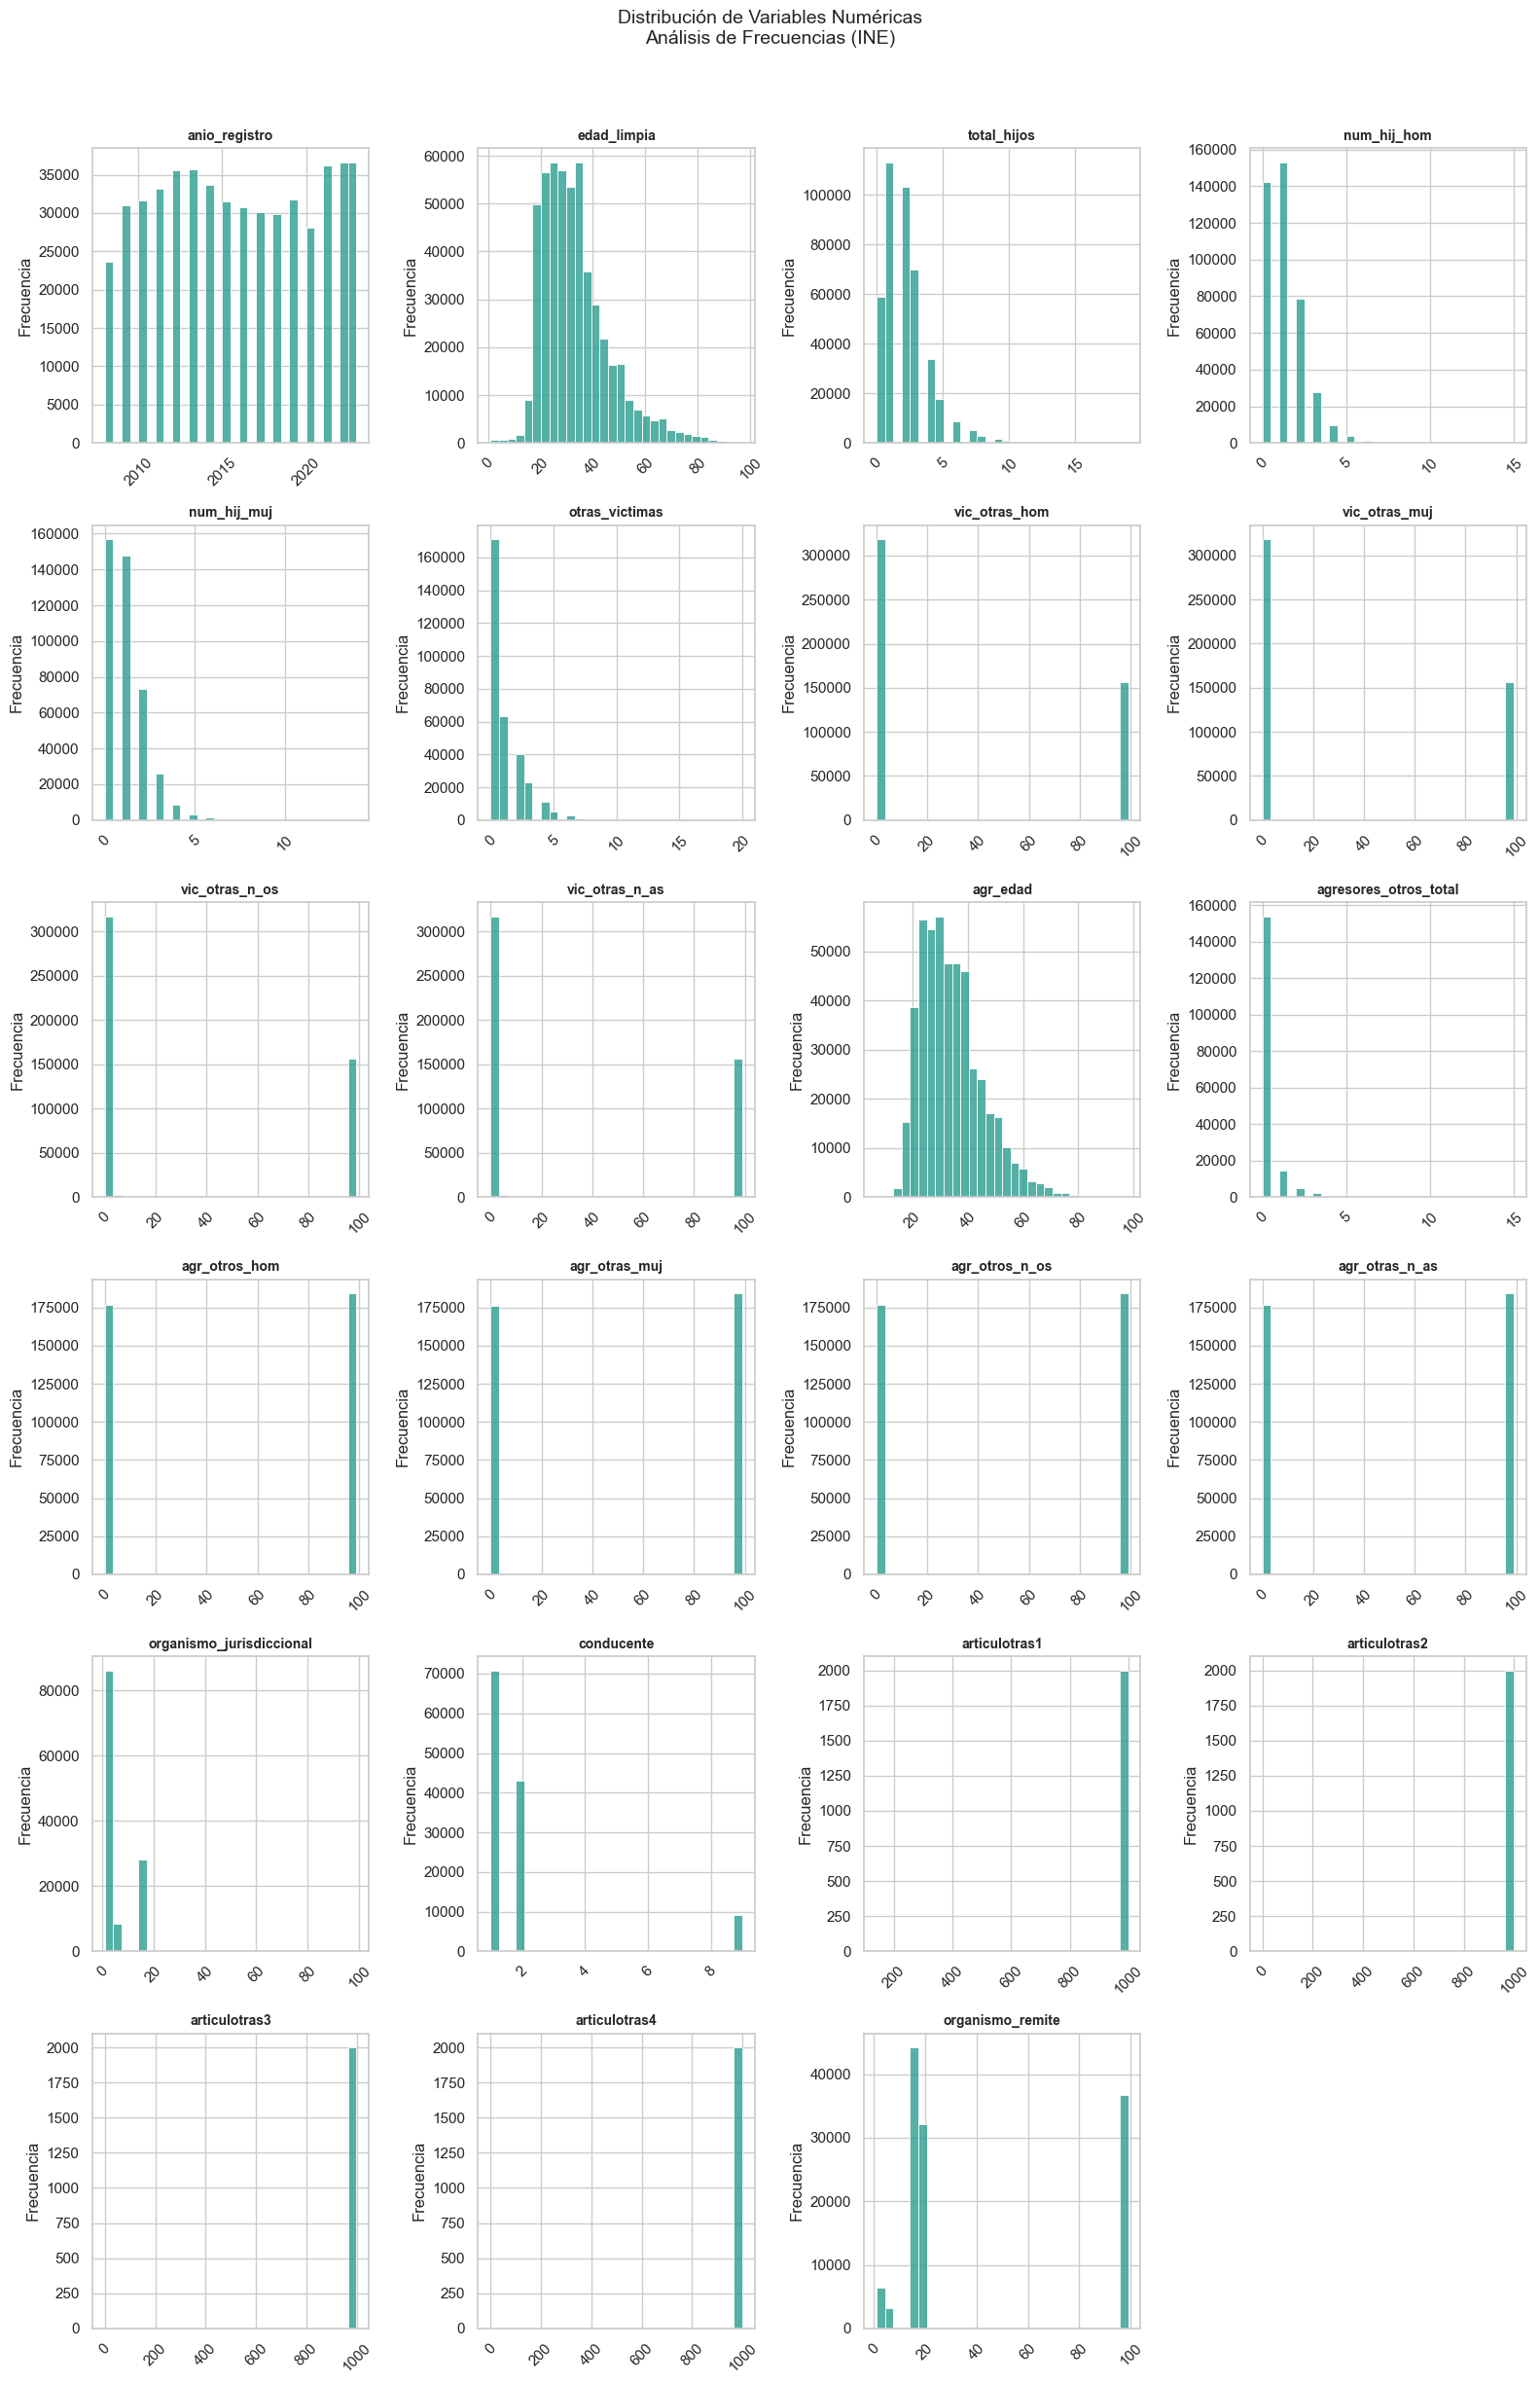

Resumen estadístico generado.


In [41]:
resumen_estadistico = generar_exploracion(df)
print("Resumen estadístico generado.")

## 4. Evaluación Preliminar de Normalidad

In [42]:
def prueba_normalidad(df):
    print("Generando Q-Q Plots...")
    df_muestra = df.sample(n=min(5000, len(df)), random_state=123)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    if "edad_limpia" in df_muestra.columns:
        stats.probplot(df_muestra["edad_limpia"].dropna(), dist="norm", plot=axes[0])
        axes[0].set_title("Q-Q Plot: Edad Víctima")
        axes[0].get_lines()[1].set_color("red")
    else:
        axes[0].set_title("edad_limpia no disponible")
        axes[0].text(0.5, 0.5, "Columna ausente", ha="center", va="center")

    if "total_hijos" in df_muestra.columns:
        stats.probplot(df_muestra["total_hijos"].dropna(), dist="norm", plot=axes[1])
        axes[1].set_title("Q-Q Plot: Total Hijos")
        axes[1].get_lines()[1].set_color("red")
    else:
        axes[1].set_title("total_hijos no disponible")
        axes[1].text(0.5, 0.5, "Columna ausente", ha="center", va="center")

    plt.tight_layout()
    plt.show()

Generando Q-Q Plots...


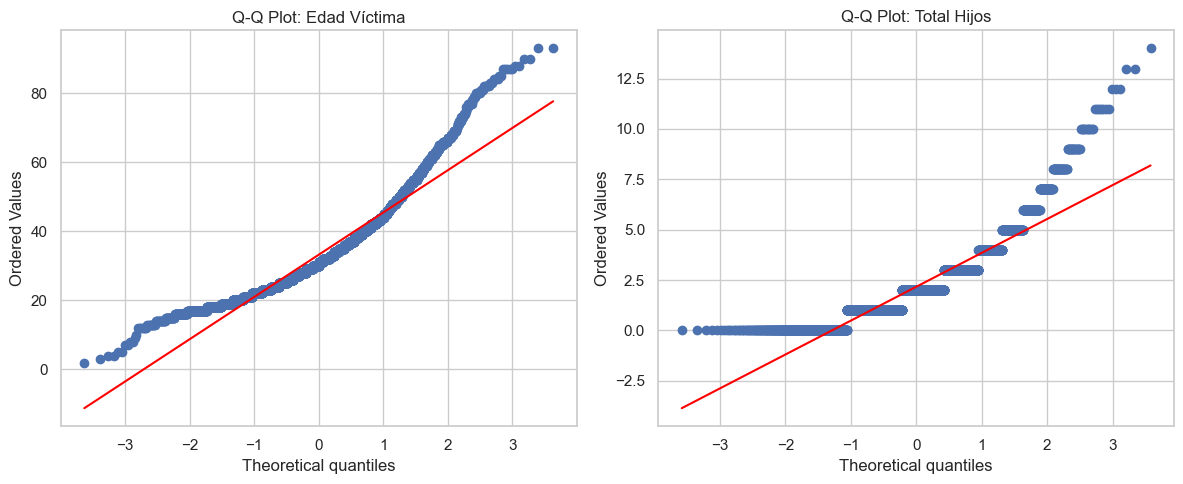

Q-Q plots generados.


In [43]:
prueba_normalidad(df)
print("Q-Q plots generados.")

## 5. Modelado No Supervisado: Clustering K-Means

In [44]:
def realizar_clustering(df):
    print("Preparando variables para clustering...")

    features_modelo = ["edad_limpia", "total_hijos", "vic_trabaja_num"]

    faltantes = [c for c in ["edad_limpia", "total_hijos", "vic_trabaja"] if c not in df.columns]
    if faltantes:
        raise ValueError(f"No se encontraron columnas requeridas para clustering: {faltantes}")

    df_cluster = df[["edad_limpia", "total_hijos", "vic_trabaja"]].copy()

    def _fix_mojibake_local(texto):
        if pd.isna(texto):
            return np.nan
        s = str(texto)
        if "Ã" in s or "Â" in s:
            try:
                return s.encode("latin1").decode("utf-8")
            except (UnicodeEncodeError, UnicodeDecodeError):
                return s
        return s

    # Mapeo robusto de vic_trabaja a numérico.
    vic_raw = df_cluster["vic_trabaja"].apply(_fix_mojibake_local).astype(str).str.strip().str.lower()
    mapa_trabaja = {
        "si": 1,
        "si trabaja por un salario o ingreso": 1,
        "sí": 1,
        "no": 0,
        "no trabaja por un salario o ingreso": 0,
        "no_especifica": 0,
    }
    df_cluster["vic_trabaja_num"] = vic_raw.map(mapa_trabaja)
    df_cluster["vic_trabaja_num"] = df_cluster["vic_trabaja_num"].fillna(0)

    # Se eliminan filas incompletas en las variables que alimentan el modelo.
    df_cluster = df_cluster.dropna(subset=["edad_limpia", "total_hijos"]).copy()

    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df_cluster[features_modelo])

    print("Ejecutando K-Means (k=3)...")
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df_cluster["Cluster"] = kmeans.fit_predict(df_scaled)

    centroides = pd.DataFrame(
        scaler.inverse_transform(kmeans.cluster_centers_),
        columns=features_modelo
    )
    centroides.index.name = "Cluster"

    print("\nCentroides de los clústeres (espacio escalado inverso):")
    display(centroides)

    # Visualización según clústeres multidimensionales.
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x="edad_limpia",
        y="total_hijos",
        hue="Cluster",
        data=df_cluster,
        palette="viridis",
        alpha=0.5
    )
    plt.title("Segmentación de Perfiles de Víctimas")
    plt.tight_layout()
    plt.show()

    return df_cluster, centroides

Preparando variables para clustering...
Ejecutando K-Means (k=3)...

Centroides de los clústeres (espacio escalado inverso):


,edad_limpia,total_hijos,vic_trabaja_num
Cluster,,,
0,32.955008,1.831832,1.000000e+00
1,49.471030,4.579173,1.634945e-01
2,27.554473,1.525342,2.020606e-14


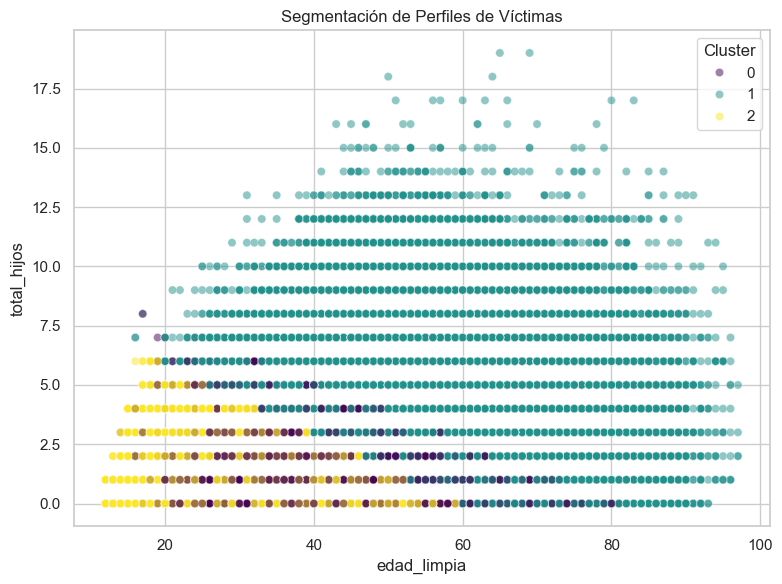

Clustering realizado.


In [45]:
df_cluster, centroides = realizar_clustering(df)
print("Clustering realizado.")

## 6. Síntesis de Resultados

En las celdas de código anteriores, se unificó el proceso completo de análisis:
- Carga y limpieza desde el archivo CSV principal.
- Exploración estadística y visualización de distribuciones.
- Evaluación de normalidad para variables clave.
- Segmentación con K-Means y visualización de centroides y clústeres dentro del cuaderno.

## 7. Preparación de Datos para Modelado Supervisado

En este apartado se construye una variable respuesta binaria para estimar riesgo de violencia física y se prepara una matriz de predictores para modelos de clasificación.

### Paso 1. Transformación de la Variable Respuesta (Binarización)

Criterio aplicado sobre hec_tipagre (normalizando tildes y corrigiendo posibles errores de codificación como PsicolÃ³gica):
- Se asigna 1 si la categoría pertenece a un tipo que incluye **violencia física o sexual**.
- Se asigna 0 únicamente si la categoría corresponde a violencia sin contacto físico directo: psicológica o patrimonial.
- Valores nulos y categorías fuera de este conjunto (por ejemplo, Otros) se asignan como NaN para excluirse del entrenamiento supervisado.

In [46]:
import unicodedata

def reparar_mojibake(texto):
    if pd.isna(texto):
        return np.nan
    s = str(texto)
    # Corrige casos típicos como 'PsicolÃ³gica' -> 'Psicológica'.
    if "Ã" in s or "Â" in s:
        try:
            return s.encode("latin1").decode("utf-8")
        except (UnicodeEncodeError, UnicodeDecodeError):
            return s
    return s

def normalizar_texto_categoria(x):
    if pd.isna(x):
        return np.nan
    txt = reparar_mojibake(x)
    txt = str(txt).strip().lower()
    txt = "".join(ch for ch in unicodedata.normalize("NFKD", txt) if not unicodedata.combining(ch))
    txt = re.sub(r"\s+", " ", txt)
    return txt

# Clase 1: cualquier combinación con componente física o sexual.
categorias_riesgo_alto = {
    "fisica",
    "sexual",
    "fisica-psicologica",
    "fisica-sexual",
    "fisica-patrimonial",
    "psicologica-sexual",
    "sexual-patrimonial",
    "fisica-psicologica-sexual",
    "fisica-psicologica-patrimonial",
    "psicologica-sexual-patrimonial",
    "fisica-sexual-patrimonial",
    "fisica-psicologica-sexual-patrimonial",
}

# Clase 0: violencia sin contacto físico directo.
categorias_riesgo_bajo = {
    "psicologica",
    "patrimonial",
    "psicologica-patrimonial",
}

hec_norm = df["hec_tipagre"].apply(normalizar_texto_categoria)

# Valores fuera del esquema (incluye 'otros') y nulos quedan como NaN.
df["riesgo_violencia_fisica"] = np.select(
    [hec_norm.isin(categorias_riesgo_alto), hec_norm.isin(categorias_riesgo_bajo)],
    [1, 0],
    default=np.nan
)

print("Distribución de riesgo_violencia_fisica (incluye NaN):")
display(df["riesgo_violencia_fisica"].value_counts(dropna=False).rename("conteo").to_frame())

print("Ejemplos de categorías no mapeadas (incluye posibles 'otros'):")
display(
    df.loc[df["riesgo_violencia_fisica"].isna(), "hec_tipagre"]
      .value_counts(dropna=False)
      .head(15)
      .rename("conteo")
      .to_frame()
)

Distribución de riesgo_violencia_fisica (incluye NaN):


,conteo
riesgo_violencia_fisica,
1.0,300440
0.0,215506


Ejemplos de categorías no mapeadas (incluye posibles 'otros'):


,conteo
hec_tipagre,


Grafica de distribución:

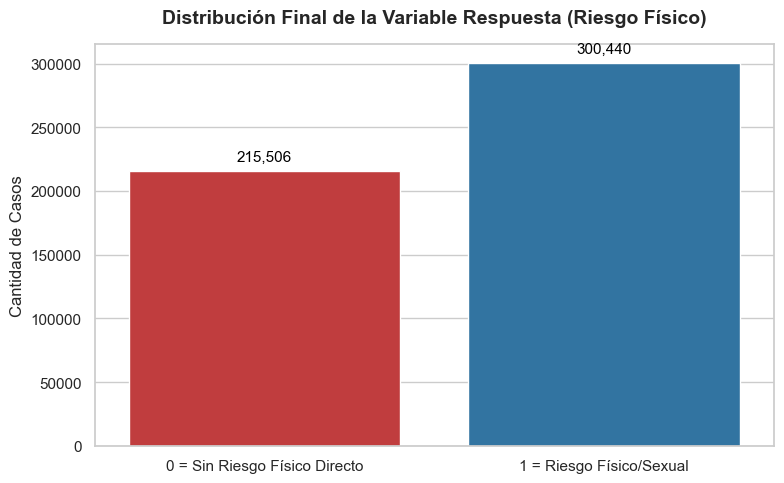

In [47]:
plot_df = df[["riesgo_violencia_fisica"]].dropna().copy()
plot_df["riesgo_violencia_fisica"] = plot_df["riesgo_violencia_fisica"].astype(int)

plot_df["Clase"] = plot_df["riesgo_violencia_fisica"].map({
    0: "0 = Sin Riesgo Físico Directo",
    1: "1 = Riesgo Físico/Sexual"
})

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Crear el gráfico de barras
ax = sns.countplot(
    data=plot_df,
    x="Clase",
    order=["0 = Sin Riesgo Físico Directo", "1 = Riesgo Físico/Sexual"],
    hue="Clase",                   
    palette=["#1f77b4", "#d62728"],
    legend=False                   
)

# Títulos y ejes
plt.title("Distribución Final de la Variable Respuesta (Riesgo Físico)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("")
plt.ylabel("Cantidad de Casos", fontsize=12)

# Agregar los números arriba de cada barra
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f"{int(altura):,}", 
                (p.get_x() + p.get_width() / 2., altura),
                ha='center', va='bottom', fontsize=11, color='black', 
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

### Paso 2. Selección de Variables Predictoras (Features)

Se retienen únicamente la variable respuesta y los predictores definidos para el problema supervisado.
En este paso, `total_hijos` se imputa con `0` (ausencia de hijos como hipótesis de trabajo), mientras que `edad_limpia` y `agr_edad` se imputan con mediana.

In [48]:
columnas_modelo = [
    "riesgo_violencia_fisica",
    "edad_limpia",
    "total_hijos",
    "agr_edad",
    "vic_rel_agr",
    "vic_trabaja",
    "hec_recur_denun",
]

df_modelo = df[columnas_modelo].copy()

# Para modelado supervisado se excluyen registros sin etiqueta binaria válida.
df_modelo = df_modelo.dropna(subset=["riesgo_violencia_fisica"]).copy()
df_modelo["riesgo_violencia_fisica"] = df_modelo["riesgo_violencia_fisica"].astype(int)

variables_numericas = ["edad_limpia", "total_hijos", "agr_edad"]

print("Faltantes numéricos antes de imputación:")
display(df_modelo[variables_numericas].isna().sum().rename("nulos").to_frame())

# Regla específica para total_hijos: nulos -> 0
df_modelo["total_hijos"] = df_modelo["total_hijos"].fillna(0)

# Para edad_limpia y agr_edad se usa imputación por mediana.
for col in ["edad_limpia", "agr_edad"]:
    df_modelo[col] = df_modelo[col].fillna(df_modelo[col].median())

# Transformación de recurrencia de denuncia: Si -> 1, No -> 0, nulos -> 0.
mapa_recurrencia = {"si": 1, "no": 0}
df_modelo["hec_recur_denun"] = (
    df_modelo["hec_recur_denun"]
    .apply(reparar_mojibake)
    .astype(str)
    .str.strip()
    .str.lower()
    .map(mapa_recurrencia)
    .fillna(0)
    .astype(int)
)

# Reutilización de la etiqueta de clúster desde df_cluster por índice (left join).
df_modelo = df_modelo.join(df_cluster[["Cluster"]], how="left")
df_modelo["Cluster"] = df_modelo["Cluster"].fillna(-1).astype(int).astype(str)
df_modelo["Cluster"] = df_modelo["Cluster"].replace({"-1": "Sin_Cluster"})

print("Faltantes numéricos después de imputación:")
display(df_modelo[variables_numericas].isna().sum().rename("nulos").to_frame())

print("Distribución de hec_recur_denun:")
display(df_modelo["hec_recur_denun"].value_counts(dropna=False).rename("conteo").to_frame())

print("Distribución de Cluster (con Sin_Cluster):")
display(df_modelo["Cluster"].value_counts(dropna=False).rename("conteo").to_frame())

print("Dimensión del dataset para modelado:", df_modelo.shape)
display(df_modelo.head())

Faltantes numéricos antes de imputación:


,nulos
edad_limpia,6927
total_hijos,98320
agr_edad,33565


Faltantes numéricos después de imputación:


,nulos
edad_limpia,0
total_hijos,0
agr_edad,0


Distribución de hec_recur_denun:


,conteo
hec_recur_denun,
0,454621
1,61325


Distribución de Cluster (con Sin_Cluster):


,conteo
Cluster,
2,212793
0,127224
Sin_Cluster,102110
1,73819


Dimensión del dataset para modelado: (515946, 8)


,riesgo_violencia_fisica,edad_limpia,total_hijos,agr_edad,vic_rel_agr,vic_trabaja,hec_recur_denun,Cluster
0,1,21.0,2.0,25.0,Conviviente,Si trabaja por un salario o ingreso,0,0
1,1,43.0,3.0,32.0,Esposos(a),Si trabaja por un salario o ingreso,0,0
2,0,43.0,2.0,41.0,Ex-cónyuges,Si trabaja por un salario o ingreso,1,0
3,1,35.0,3.0,35.0,Esposos(a),No trabaja por un salario o ingreso,0,2
4,1,26.0,3.0,27.0,Esposos(a),No trabaja por un salario o ingreso,0,2


### Paso 3 y 4. Escalamiento Numérico y Encoding Categórico

Se utiliza **MinMaxScaler** porque en el análisis exploratorio las variables numéricas no siguen normalidad; este escalador no asume distribución normal y lleva cada variable al rango [0, 1], facilitando comparabilidad para modelos lineales y basados en distancia.

In [49]:
variables_numericas = ["edad_limpia", "total_hijos", "agr_edad"]
variables_binarias = ["hec_recur_denun"]
variables_categoricas = ["vic_rel_agr", "vic_trabaja", "Cluster"]

df_prep = df_modelo.copy()

# Elegimos MinMaxScaler por no requerir normalidad y acotar escala a [0, 1].
scaler = MinMaxScaler()
df_prep[variables_numericas] = scaler.fit_transform(df_prep[variables_numericas])

def normalizar_texto_cat(valor):
    if pd.isna(valor):
        return ""
    txt = reparar_mojibake(valor)
    txt = str(txt).strip().lower()
    txt = "".join(ch for ch in unicodedata.normalize("NFKD", txt) if not unicodedata.combining(ch))
    txt = re.sub(r"\s+", " ", txt)
    return txt

def agrupar_vic_rel_agr(valor):
    txt = normalizar_texto_cat(valor)

    grupo_pareja = {
        "esposos (a)",
        "esposos(a)",
        "esposos (as)",
        "esposos(as)",
        "conviviente",
        "ex-conyuges",
        "ex conyuges",
    }
    grupo_familia = {
        "padres/madres",
        "hijos(as)",
        "hermanos(as)",
        "nietos(as)",
        "suegros(as)",
        "hijastros(as)",
        "otro pariente",
    }

    if txt in grupo_pareja:
        return "Pareja"
    if txt in grupo_familia:
        return "Familia"
    return "Otros"

def estandarizar_vic_trabaja(valor):
    txt = normalizar_texto_cat(valor)

    categoria_si = {
        "si",
        "sí",
        "si trabaja por un salario o ingreso",
        "si trabaja por salario o ingreso",
    }
    categoria_no = {
        "no",
        "no trabaja por un salario o ingreso",
        "no trabaja por salario o ingreso",
    }

    if txt in categoria_si:
        return "Si"
    if txt in categoria_no:
        return "No"
    return "No_especifica"

# Agrupación de vic_rel_agr en tres macrogrupos: Pareja, Familia y Otros.
df_prep["vic_rel_agr"] = df_prep["vic_rel_agr"].apply(agrupar_vic_rel_agr)

# Normalización robusta de vic_trabaja
df_prep["vic_trabaja"] = df_prep["vic_trabaja"].apply(estandarizar_vic_trabaja)

# Cluster se mantiene como categórica para pasar por One-Hot Encoding.
df_prep["Cluster"] = df_prep["Cluster"].fillna("Sin_Cluster").astype(str)

# Forzamos 3 categorías en las variables clave para controlar el número de dummies con drop_first=True.
df_prep["vic_rel_agr"] = pd.Categorical(
    df_prep["vic_rel_agr"],
    categories=["Pareja", "Familia", "Otros"]
)
df_prep["vic_trabaja"] = pd.Categorical(
    df_prep["vic_trabaja"],
    categories=["No", "Si", "No_especifica"]
)

# En categóricas, convertimos nulos a etiqueta.
for col in variables_categoricas:
    df_prep[col] = df_prep[col].fillna("No_especifica")

X = pd.get_dummies(
    df_prep[variables_numericas + variables_binarias + variables_categoricas],
    columns=variables_categoricas,
    drop_first=True,
    dtype=int
)
y = df_prep["riesgo_violencia_fisica"]

dummies_vic_trabaja = [c for c in X.columns if c.startswith("vic_trabaja_")]
dummies_vic_rel_agr = [c for c in X.columns if c.startswith("vic_rel_agr_")]

print("Matriz de predictores X:", X.shape)
print("Vector respuesta y:", y.shape)
print("Categorías vic_trabaja normalizadas:", list(df_prep["vic_trabaja"].cat.categories))
print("Categorías vic_rel_agr agrupadas:", list(df_prep["vic_rel_agr"].cat.categories))
print("Dummies vic_trabaja:", len(dummies_vic_trabaja), dummies_vic_trabaja)
print("Dummies vic_rel_agr:", len(dummies_vic_rel_agr), dummies_vic_rel_agr)
display(X.head())

print("Columnas generadas en X:")
display(pd.DataFrame({"columna": X.columns}).head(140))
display(y.value_counts().rename("conteo").to_frame())

Matriz de predictores X: (515946, 11)
Vector respuesta y: (515946,)
Categorías vic_trabaja normalizadas: ['No', 'Si', 'No_especifica']
Categorías vic_rel_agr agrupadas: ['Pareja', 'Familia', 'Otros']
Dummies vic_trabaja: 2 ['vic_trabaja_Si', 'vic_trabaja_No_especifica']
Dummies vic_rel_agr: 2 ['vic_rel_agr_Familia', 'vic_rel_agr_Otros']


,edad_limpia,total_hijos,agr_edad,hec_recur_denun,vic_rel_agr_Familia,vic_rel_agr_Otros,vic_trabaja_Si,vic_trabaja_No_especifica,Cluster_1,Cluster_2,Cluster_Sin_Cluster
0,0.208333,0.105263,0.197802,0,0,0,1,0,0,0,0
1,0.437500,0.157895,0.274725,0,0,0,1,0,0,0,0
2,0.437500,0.105263,0.373626,1,0,0,1,0,0,0,0
3,0.354167,0.157895,0.307692,0,0,0,0,0,0,1,0
4,0.260417,0.157895,0.219780,0,0,0,0,0,0,1,0


Columnas generadas en X:


,columna
0,edad_limpia
1,total_hijos
2,agr_edad
3,hec_recur_denun
4,vic_rel_agr_Familia
5,vic_rel_agr_Otros
6,vic_trabaja_Si
7,vic_trabaja_No_especifica
8,Cluster_1
9,Cluster_2


,conteo
riesgo_violencia_fisica,
1,300440
0,215506


## Modelado Supervisado: Entrenamiento y Evaluación

Se entrenan cuatro clasificadores sobre la matriz `X` y el vector respuesta `y` obtenidos en la sección anterior:
- **CART** (Árbol de Decisión): interpretable, permite visualizar reglas.
- **Random Forest**: conjunto de árboles, reduce varianza.
- **KNN** (k vecinos más cercanos): basado en distancia, sensible a escala.
- **Regresión Logística**: modelo lineal, coeficientes interpretables.

División: 80 % entrenamiento / 20 % prueba con estratificación.

### Paso 5. División Train / Test

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} filas  |  Test: {X_test.shape[0]:,} filas")
print(f"Proporción clase 1 en train: {y_train.mean():.3f}")
print(f"Proporción clase 1 en test:  {y_test.mean():.3f}")

Train: 412,756 filas  |  Test: 103,190 filas
Proporción clase 1 en train: 0.582
Proporción clase 1 en test:  0.582


### Paso 6. Entrenamiento de los Cuatro Modelos

In [51]:
import warnings
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

modelos = {
    "CART": DecisionTreeClassifier(max_depth=6, min_samples_leaf=50, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=11, n_jobs=-1),
    "Regresión Logística": LogisticRegression(max_iter=500, random_state=42),
}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    print(f"{nombre} entrenado.")

CART entrenado.
Random Forest entrenado.
KNN entrenado.
Regresión Logística entrenado.


### Paso 7. Evaluación: Classification Report y Accuracy

In [52]:
from sklearn.metrics import classification_report, accuracy_score

resumen_modelos = []

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    resumen_modelos.append({"Modelo": nombre, "Accuracy": acc})
    print(f"  Modelo: {nombre}  |  Accuracy: {acc:.4f}")
    print('-'*55)
    print(classification_report(y_test, y_pred, target_names=["No físico (0)", "Físico (1)"]))

df_resumen = pd.DataFrame(resumen_modelos).sort_values("Accuracy", ascending=False)
display(df_resumen.reset_index(drop=True))

  Modelo: CART  |  Accuracy: 0.6120
-------------------------------------------------------
               precision    recall  f1-score   support

No físico (0)       0.56      0.31      0.40     43102
   Físico (1)       0.63      0.83      0.71     60088

     accuracy                           0.61    103190
    macro avg       0.60      0.57      0.56    103190
 weighted avg       0.60      0.61      0.58    103190

  Modelo: Random Forest  |  Accuracy: 0.6149
-------------------------------------------------------
               precision    recall  f1-score   support

No físico (0)       0.57      0.33      0.42     43102
   Físico (1)       0.63      0.82      0.71     60088

     accuracy                           0.61    103190
    macro avg       0.60      0.57      0.56    103190
 weighted avg       0.60      0.61      0.59    103190

  Modelo: KNN  |  Accuracy: 0.5802
-------------------------------------------------------
               precision    recall  f1-score   sup

,Modelo,Accuracy
0,Random Forest,0.614934
1,CART,0.611988
2,Regresión Logística,0.607559
3,KNN,0.580202


### Paso 8. Comparativa Visual de Accuracy

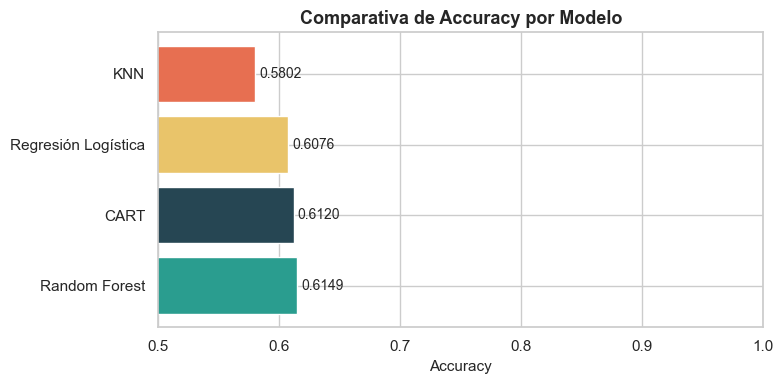

In [53]:
fig, ax = plt.subplots(figsize=(8, 4))
colores = ["#2A9D8F", "#264653", "#E9C46A", "#E76F51"]
bars = ax.barh(
    df_resumen["Modelo"],
    df_resumen["Accuracy"],
    color=colores[:len(df_resumen)],
    edgecolor="white"
)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel("Accuracy", fontsize=11)
ax.set_title("Comparativa de Accuracy por Modelo", fontsize=13, fontweight="bold")
for bar, val in zip(bars, df_resumen["Accuracy"]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=10)
plt.tight_layout()
plt.show()

### Paso 9. Matrices de Confusión

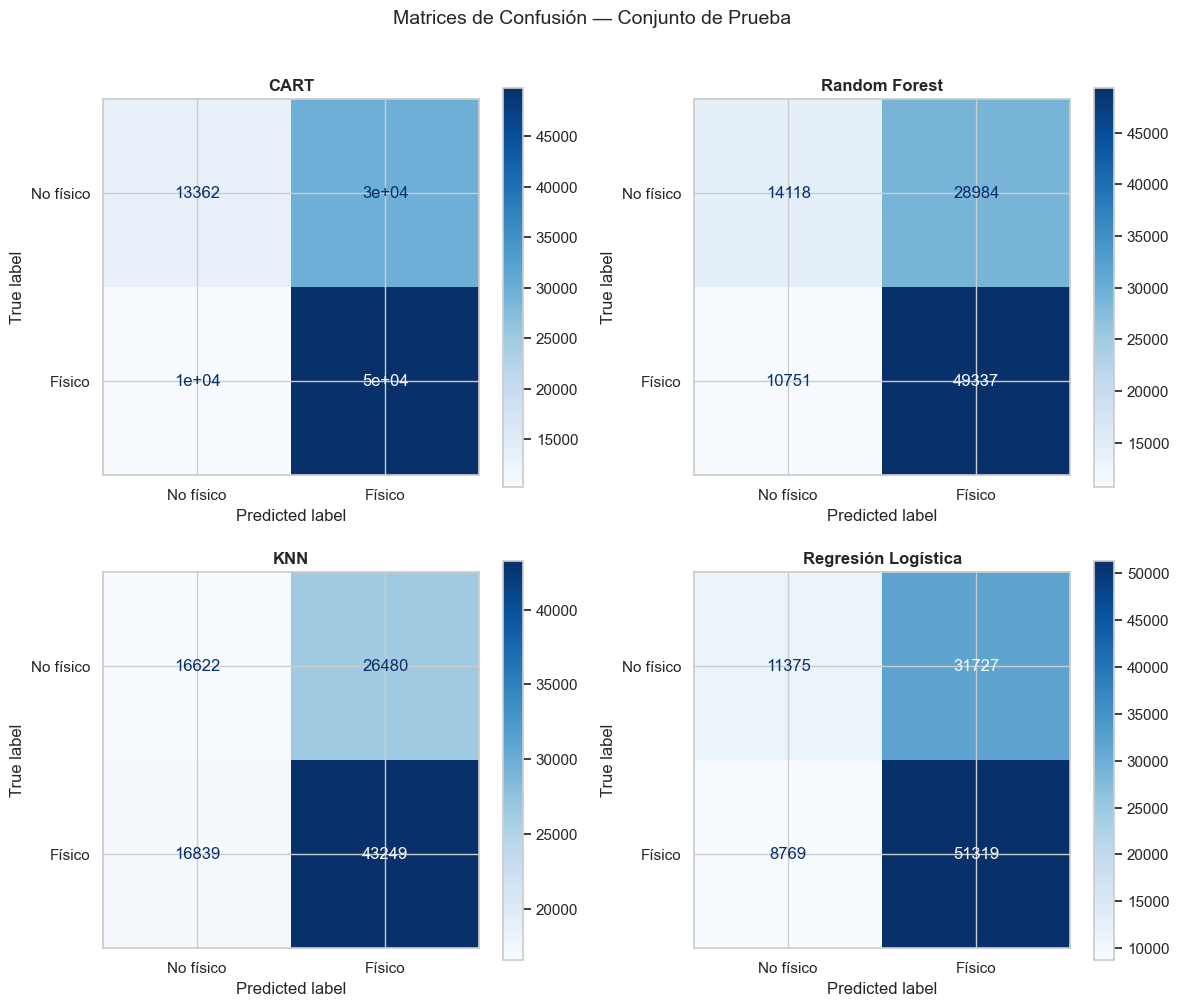

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (nombre, modelo) in zip(axes, modelos.items()):
    y_pred = modelo.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["No físico", "Físico"],
        cmap="Blues",
        ax=ax
    )
    ax.set_title(nombre, fontweight="bold")

plt.suptitle("Matrices de Confusión — Conjunto de Prueba", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Paso 10. Importancia de Variables (CART y Random Forest)

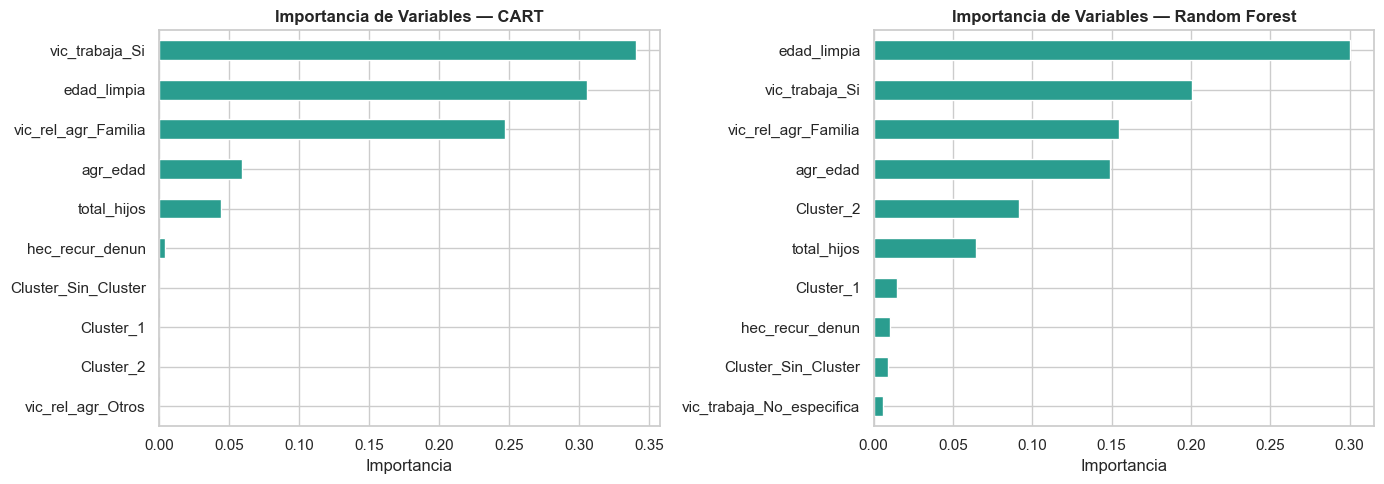

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, nombre in zip(axes, ["CART", "Random Forest"]):
    imp = pd.Series(
        modelos[nombre].feature_importances_,
        index=X.columns
    ).sort_values()
    imp.tail(10).plot(kind="barh", ax=ax, color="#2A9D8F", edgecolor="white")
    ax.set_title(f"Importancia de Variables — {nombre}", fontweight="bold")
    ax.set_xlabel("Importancia")

plt.tight_layout()
plt.show()

### Paso 11. Visualización del Árbol CART (profundidad 3)

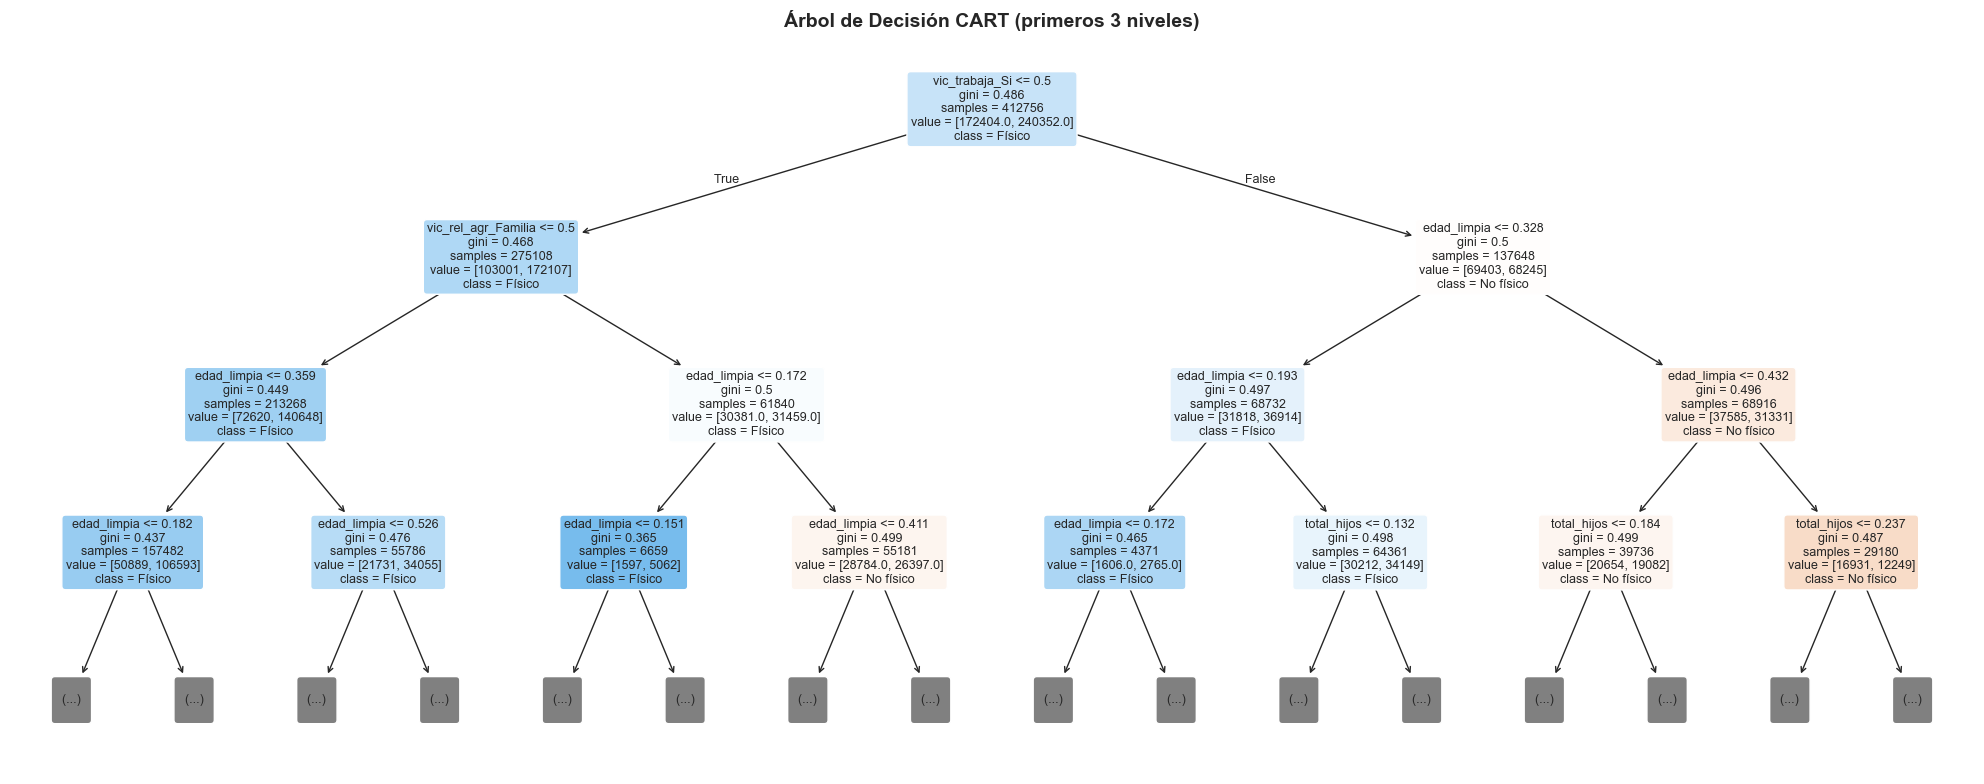

In [56]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    modelos["CART"],
    max_depth=3,
    feature_names=list(X.columns),
    class_names=["No físico", "Físico"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title("Árbol de Decisión CART (primeros 3 niveles)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Paso 12. Curvas ROC

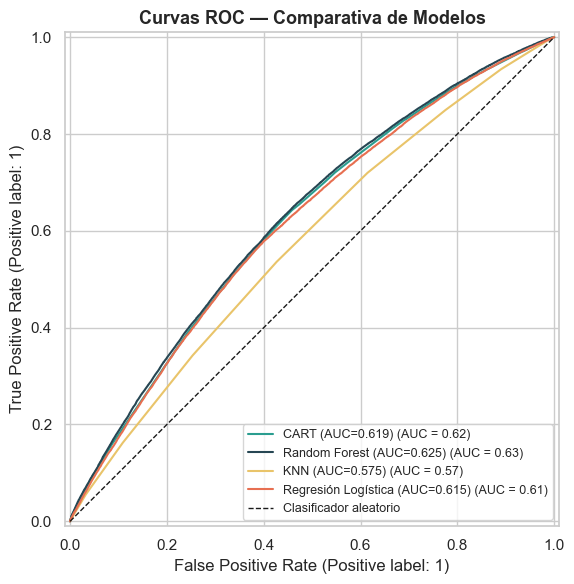

In [57]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 6))
colores_roc = ["#2A9D8F", "#264653", "#E9C46A", "#E76F51"]

for (nombre, modelo), color in zip(modelos.items(), colores_roc):
    if hasattr(modelo, "predict_proba"):
        y_prob = modelo.predict_proba(X_test)[:, 1]
    else:
        y_prob = modelo.decision_function(X_test)
    auc = roc_auc_score(y_test, y_prob)
    RocCurveDisplay.from_predictions(
        y_test, y_prob,
        name=f"{nombre} (AUC={auc:.3f})",
        color=color,
        ax=ax
    )

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Clasificador aleatorio")
ax.set_title("Curvas ROC — Comparativa de Modelos", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## Conclusiones del Modelado

Las celdas anteriores completan el flujo supervisado:
1. **División** estratificada 80/20 para preservar la proporción de clases.
2. **Entrenamiento** de CART, Random Forest, KNN y Regresión Logística sobre la misma matriz `X`.
3. **Evaluación** con accuracy, reporte de clasificación (precision/recall/F1), matrices de confusión y curvas ROC-AUC.
4. **Interpretabilidad**: importancia de variables en modelos basados en árboles y visualización del árbol CART a profundidad 3.

> La variable respuesta `riesgo_violencia_fisica` se construyó en el Paso 1 normalizando tildes y corrigiendo mojibake, asignando **1** a categorías con componente física o sexual, **0** a violencia exclusivamente psicológica/patrimonial, y **NaN** a categorías ambiguas o nulas, que se excluyen del entrenamiento.